# 13_01.Tensorflow(기본모델만들기)
- https://www.tensorflow.org/tutorials/quickstart/beginner?hl=ko

## 1.기본 package 설정

In [ ]:
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기

import tensorflow as tf
from tensorflow import keras
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.12.0


## 2.데이터 불러오기

### 2.1 데이터 불러오기

In [ ]:
(X_train, y_train),(X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
y_train.shape

(60000,)

### 2.2 자료구조 살펴보기

In [ ]:
X_train[y_train == 0][0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

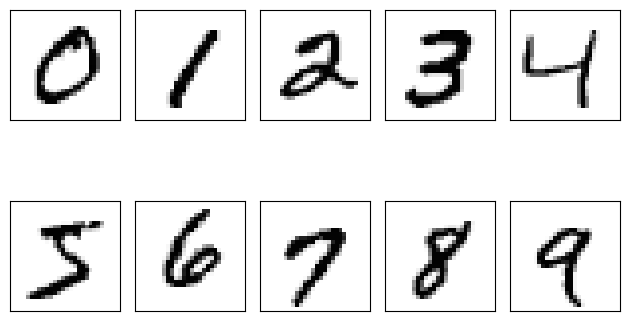

In [ ]:
# 1-10번 글짜 샘플 보기

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)

ax = ax.flatten()   # flatten: 다차원 배열 공간을 1차원

for i in range(10):
    img = X_train[y_train == i][0].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

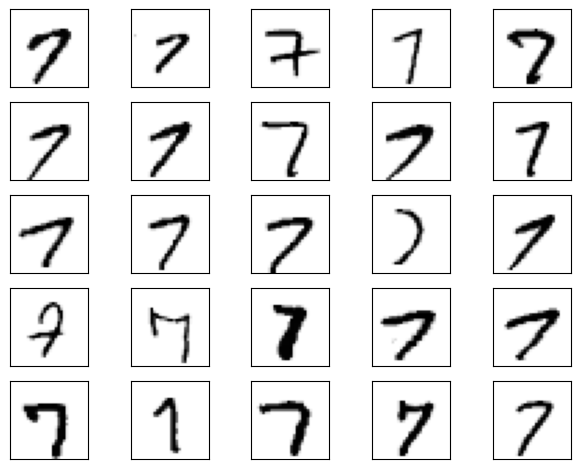

In [ ]:
# 7번 글짜만 보기
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)

ax = ax.flatten()

for i in range(25):
    img = X_train[y_train == 7][i].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
print(X_train.shape, X_train.dtype)
print(X_test.shape, X_test.dtype)

(60000, 28, 28) uint8
(10000, 28, 28) uint8


In [ ]:
print(y_train.shape, y_train.dtype)
print(y_test.shape, y_test.dtype)

(60000,) uint8
(10000,) uint8


## 3.신경망

### 3.1 신경망 구성


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),     # 28 * 28 = 784
    tf.keras.layers.Dense(50, activation='relu'),      # 784*50+50(절편)
    tf.keras.layers.Dense(50, activation='relu'),      # 784*50+50(절편)
    tf.keras.layers.Dropout(0.2),                      # 과적합방지
    # 각 클래스의 확률을 계산하기 위해 softmax 사용
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                510       
                                                                 
Total params: 42,310
Trainable params: 42,310
Non-trainable params: 0
_________________________________________________________________


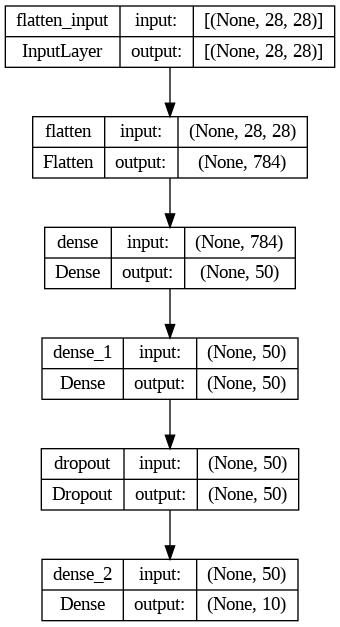

In [ ]:
tf.keras.utils.plot_model(model,
                          show_shapes = True,
                          to_file='model.png')

### 3.2 신경망 훈련
- 이진 분류 : binary_crossentropy
- 다중 분류 : sparse_categorical_crossentropy

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
np.random.seed(1)

history = model.fit(X_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1, # 검증용 데이터 10% 추출해서 훈련시 검정
                    verbose = 1)

Epoch 1/10
844/844 [==============================] - 9s 5ms/step - loss: 2.8813 - accuracy: 0.5785 - val_loss: 0.7218 - val_accuracy: 0.8123
Epoch 2/10
844/844 [==============================] - 4s 4ms/step - loss: 0.7716 - accuracy: 0.8015 - val_loss: 0.4786 - val_accuracy: 0.8688
Epoch 3/10
844/844 [==============================] - 3s 3ms/step - loss: 0.5143 - accuracy: 0.8647 - val_loss: 0.3666 - val_accuracy: 0.8978
Epoch 4/10
844/844 [==============================] - 3s 4ms/step - loss: 0.3918 - accuracy: 0.8955 - val_loss: 0.2611 - val_accuracy: 0.9313
Epoch 5/10
844/844 [==============================] - 3s 4ms/step - loss: 0.3279 - accuracy: 0.9112 - val_loss: 0.2405 - val_accuracy: 0.9343
Epoch 6/10
844/844 [==============================] - 3s 3ms/step - loss: 0.2976 - accuracy: 0.9201 - val_loss: 0.2359 - val_accuracy: 0.9342
Epoch 7/10
844/844 [==============================] - 3s 3ms/step - loss: 0.2770 - accuracy: 0.9254 - val_loss: 0.2158 - val_accuracy: 0.9420
Epoch 

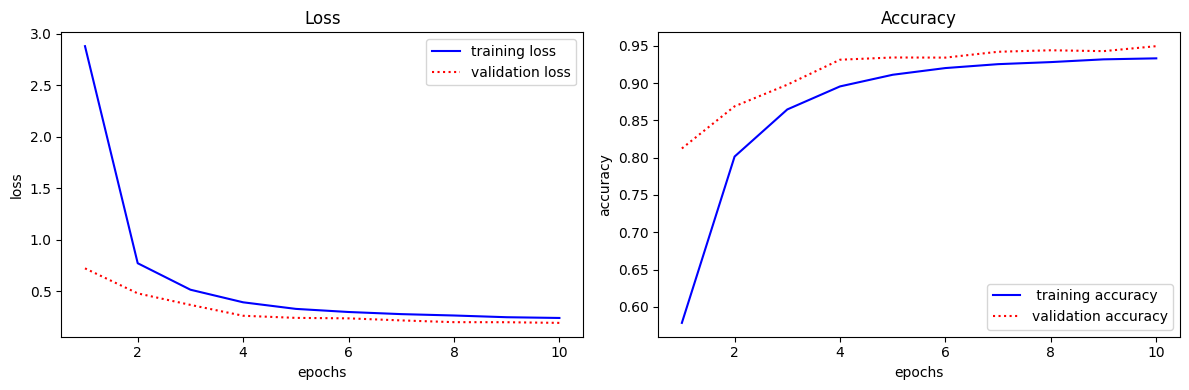

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss)+1)

fig ,ax = plt.subplots(figsize=(10, 7))

# 비용함수
plt.subplot(1, 2, 1)
plt.title("Loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(epochs, loss, 'b-', label='training loss')
plt.plot(epochs, val_loss, 'r:', label='validation loss')
plt.legend()

# 정확도
plt.subplot(1, 2, 2)
plt.title("Accuracy")
plt.ylabel("accuracy")
plt.xlabel('epochs')
plt.plot(epochs, accuracy, 'b-', label=" training accuracy")
plt.plot(epochs, val_accuracy, 'r:', label="validation accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 4.모델검정


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('test 비용: %.4f%%' % (100 * test_loss))
print('test 정확도: %.4f%%' % (100 * test_acc))

313/313 [==============================] - 1s 2ms/step - loss: 0.2187 - accuracy: 0.9390
test 비용: 0.2187%
test 정확도: 0.9390%
